# VIX ETN Dual — Implementation Comparison

Loads canonical (eVRP+BoC+Sizing) strategy from `results/vix_etn_dual_trades.csv`.

**Architecture:** Portfolio-level (single sleeve, dynamically allocates between VIXSHORT and VIXLONG). Like QMom, sizing is determined at the signal level (entry weight = VIX/100 or 0.5 × VIX/100). So Implementation focuses on **portfolio-level leverage** rather than per-trade sizing.

**Sizing variants:**
- Simple bet at varying leverage levels (1×, 1.5×, 2×)
- Comparison vs SPY at matched drawdown

**Note:** Risk-based and Kelly are not meaningful here:
- Risk-based requires a stop loss — VIX ETN strategy has none (held until next signal flip)
- Kelly: VIX ETN trades are highly skewed (many small wins, occasional huge losses during vol spikes). Kelly fraction would be unstable.

**Note on leverage:** VIXSHORT is already a synthetic -1× short-vol product. Adding leverage to the strategy means amplifying the strategy's return stream, NOT adding more leverage to SVXY. Cap at 2× — beyond that, drawdowns during 2018 Volmageddon, COVID, etc., become catastrophic.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STARTING_CAPITAL = 100_000
STRATEGY_NAME = "VIX ETN Dual"
SAVE_NAME     = "vix_etn_dual"

pd.set_option("display.max_columns", None)

## 2. Load Canonical Strategy + Pre-Computed Equity

In [2]:
trades = pd.read_csv(f"results/{SAVE_NAME}_trades.csv",
                      parse_dates=["entry_time", "exit_time"])
print(f"Loaded {len(trades):,} trades")
print(f"Period: {trades['entry_time'].min().date()} → {trades['exit_time'].max().date()}")
print(f"By instrument: {dict(trades['instrument'].value_counts())}")
print(f"Avg hold days: {(trades['exit_time'] - trades['entry_time']).dt.days.mean():.1f}")
print(f"Win rate (gross): {(trades['pct_return_gross'] > 0).mean()*100:.1f}%")

STD_COLS = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
missing = [c for c in STD_COLS if c not in trades.columns]
assert not missing, f"Missing standard columns: {missing}"
print(f"Schema OK — {len(STD_COLS)} standard columns present")

Loaded 158 trades
Period: 2016-01-19 → 2025-04-25
By instrument: {'vixshort': 116, 'vixlong': 42}
Avg hold days: 5.3
Win rate (gross): 57.0%
Schema OK — 9 standard columns present


In [3]:
# Load summary to find canonical strategy name
with open(f"results/{SAVE_NAME}_summary.json") as f:
    summary = json.load(f)

canonical = summary["canonical_strategy"]
print(f"Canonical strategy from backtest: {canonical}")

safe = canonical.replace("+", "_").replace(" ", "_").lower()
eq_canon = pd.read_csv(f"results/{SAVE_NAME}_daily_equity_{safe}.csv",
                        parse_dates=[0], index_col=0).iloc[:, 0]
eq_canon.name = "equity"
ret_canon = eq_canon.pct_change().fillna(0)

# SPY benchmark
eq_spy = pd.read_csv(f"results/{SAVE_NAME}_daily_equity_spybench.csv",
                      parse_dates=[0], index_col=0).iloc[:, 0]
ret_spy = eq_spy.pct_change().fillna(0)

print(f"Loaded {len(eq_canon):,} daily equity points")
print(f"  Stats: {summary['variants'][canonical]['stats']}")

Canonical strategy from backtest: eVRP+BoC+Sizing
Loaded 2,565 daily equity points
  Stats: {'total_return': 309.4, 'cagr': 14.85, 'sharpe': 0.81, 'max_dd': -33.1}


## 3. Leverage Sweep on Canonical Strategy

In [4]:
def stats_from_eq(eq, ret, starting_capital=STARTING_CAPITAL):
    daily_r = ret.dropna()
    sharpe = daily_r.mean() / daily_r.std() * np.sqrt(252) if daily_r.std() > 0 else 0
    peak = eq.expanding().max()
    max_dd = ((eq - peak) / peak).min() * 100
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1] / starting_capital) ** (1/years) - 1) * 100 if years > 0 else 0
    tot = (eq.iloc[-1] / starting_capital - 1) * 100
    return {"total_return": round(tot, 1), "cagr": round(cagr, 2),
            "sharpe": round(sharpe, 2), "max_dd": round(max_dd, 1)}

def run_lev(ret_series, leverage=1.0, label=""):
    r = ret_series * leverage
    eq = STARTING_CAPITAL * (1 + r).cumprod()
    return {"label": label, "daily_equity": eq, "daily_returns": r,
            "stats": stats_from_eq(eq, r)}

def print_comparison(results):
    print(f"{'Label':<35} {'TotRet%':>12} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
    print("-" * 80)
    for r in results:
        s = r["stats"]
        print(f"{r['label']:<35} {s['total_return']:>12,.1f} {s['cagr']:>8.2f} "
              f"{s['sharpe']:>8.2f} {s['max_dd']:>8.1f}")

In [5]:
LEVERAGES = [1.0, 1.5, 2.0]   # 3x dropped — VIX strategies blow up at high leverage

vix_results = []
spy_results = []
for lev in LEVERAGES:
    vix_results.append(run_lev(ret_canon, leverage=lev,
                                 label=f"{canonical} {lev}x"))
    spy_results.append(run_lev(ret_spy, leverage=lev, label=f"SPY {lev}x"))

print("INTERLEAVED COMPARISON — VIX ETN Dual vs SPY at same leverage:\n")
interleaved = []
for v, s in zip(vix_results, spy_results):
    interleaved.append(v)
    interleaved.append(s)
print_comparison(interleaved)

INTERLEAVED COMPARISON — VIX ETN Dual vs SPY at same leverage:

Label                                    TotRet%    CAGR%   Sharpe   MaxDD%
--------------------------------------------------------------------------------
eVRP+BoC+Sizing 1.0x                       309.4    14.83     0.85    -33.1
SPY 1.0x                                   305.2    14.71     0.87    -33.8
eVRP+BoC+Sizing 1.5x                       631.8    21.56     0.85    -46.3
SPY 1.5x                                   623.6    21.42     0.87    -47.2
eVRP+BoC+Sizing 2.0x                     1,105.0    27.65     0.85    -57.5
SPY 2.0x                                 1,091.6    27.51     0.87    -58.5


## 4. Matched-Drawdown Comparison

In [6]:
print(f"{'VIX strategy':<28} {'SPY-matched':<22} {'VIX CAGR':>10} {'SPY CAGR':>10} {'CAGR edge':>11}")
print("-" * 88)

matched_dd_edges = {}
for v in vix_results:
    target_dd = v["stats"]["max_dd"]
    best_spy = min(spy_results, key=lambda s: abs(s["stats"]["max_dd"] - target_dd))
    edge = v["stats"]["cagr"] - best_spy["stats"]["cagr"]
    matched_dd_edges[v["label"]] = {
        "matched_to":  best_spy["label"],
        "vix_dd":      v["stats"]["max_dd"],
        "spy_dd":      best_spy["stats"]["max_dd"],
        "vix_cagr":    v["stats"]["cagr"],
        "spy_cagr":    best_spy["stats"]["cagr"],
        "cagr_edge":   round(edge, 2),
    }
    print(f"{v['label']:<28} {best_spy['label']:<22} "
          f"(DD {v['stats']['max_dd']:>5.1f}%) "
          f"{v['stats']['cagr']:>10.2f} {best_spy['stats']['cagr']:>10.2f} {edge:>+10.2f}")

VIX strategy                 SPY-matched              VIX CAGR   SPY CAGR   CAGR edge
----------------------------------------------------------------------------------------
eVRP+BoC+Sizing 1.0x         SPY 1.0x               (DD -33.1%)      14.83      14.71      +0.12
eVRP+BoC+Sizing 1.5x         SPY 1.5x               (DD -46.3%)      21.56      21.42      +0.14
eVRP+BoC+Sizing 2.0x         SPY 2.0x               (DD -57.5%)      27.65      27.51      +0.14


## 5. Equity Curves

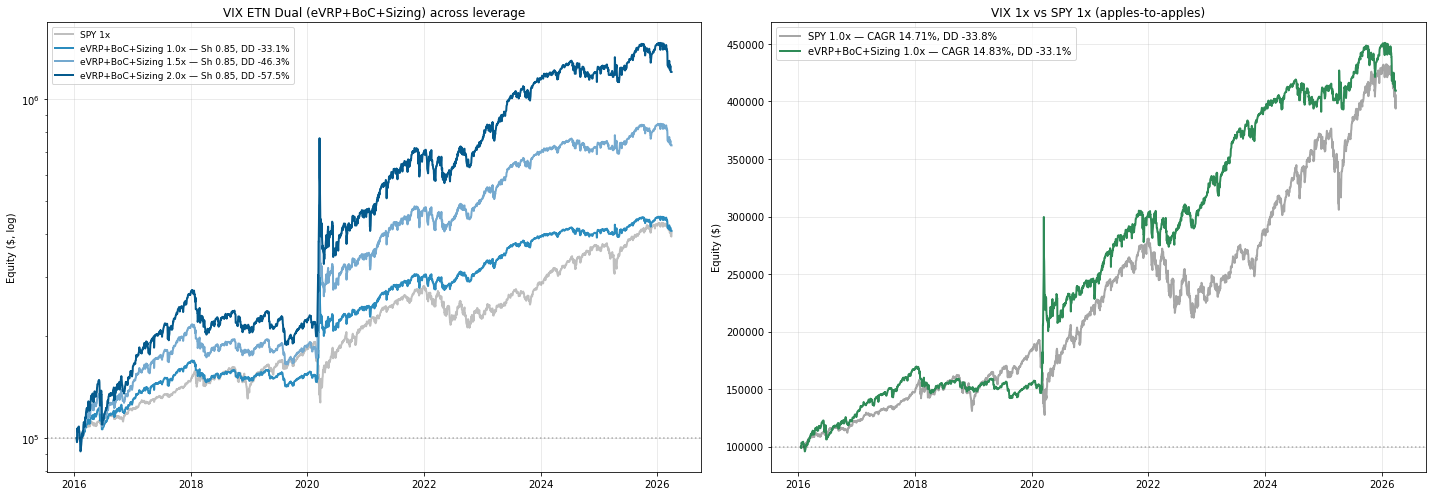

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Left: leverage sweep
ax = axes[0]
ax.plot(spy_results[0]["daily_equity"].index.to_numpy(),
        spy_results[0]["daily_equity"].values,
        color="gray", alpha=0.5, linewidth=2, label="SPY 1x")
colors = ["#2b8cbe", "#74a9cf", "#045a8d"]
for r, c in zip(vix_results, colors):
    s = r["stats"]
    ax.plot(r["daily_equity"].index.to_numpy(), r["daily_equity"].values,
            color=c, linewidth=2,
            label=f"{r['label']} — Sh {s['sharpe']}, DD {s['max_dd']}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_yscale("log")
ax.set_title(f"VIX ETN Dual ({canonical}) across leverage")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($, log)")

# Right: 1× apples-to-apples vs SPY
ax = axes[1]
v1 = vix_results[0]
s1 = spy_results[0]
ax.plot(s1["daily_equity"].index.to_numpy(), s1["daily_equity"].values,
        color="gray", linewidth=2, alpha=0.7,
        label=f"{s1['label']} — CAGR {s1['stats']['cagr']}%, DD {s1['stats']['max_dd']}%")
ax.plot(v1["daily_equity"].index.to_numpy(), v1["daily_equity"].values,
        color="seagreen", linewidth=2,
        label=f"{v1['label']} — CAGR {v1['stats']['cagr']}%, DD {v1['stats']['max_dd']}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_title("VIX 1x vs SPY 1x (apples-to-apples)")
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

## 6. Save

In [8]:
def _key(label):
    return (label.lower().replace(" ", "_").replace(".", "p")
             .replace("+", "_").replace("&", "and").replace("/", "_"))

os.makedirs("results", exist_ok=True)

all_results = vix_results + spy_results
impl_summary = {}
for r in all_results:
    k = _key(r["label"])
    impl_summary[k] = dict(r["stats"])
    impl_summary[k]["label"] = r["label"]

impl_summary["_matched_dd_edges"] = matched_dd_edges

best = max(vix_results, key=lambda r: r["stats"]["sharpe"])
impl_summary["_recommended"] = best["label"]
print(f"Best by Sharpe: {best['label']} — Sh {best['stats']['sharpe']}, "
      f"DD {best['stats']['max_dd']}%, CAGR {best['stats']['cagr']}%")

best_edge_label = max(matched_dd_edges, key=lambda k: matched_dd_edges[k]["cagr_edge"])
best_edge = matched_dd_edges[best_edge_label]
impl_summary["_best_matched_dd_edge"] = best_edge_label
print(f"\nBest matched-DD edge: {best_edge_label} vs {best_edge['matched_to']}")
print(f"  At DD ~{best_edge['vix_dd']:.1f}%: VIX CAGR {best_edge['vix_cagr']:.2f}% "
      f"vs SPY {best_edge['spy_cagr']:.2f}% (+{best_edge['cagr_edge']:.2f}pp)")

with open(f"results/{SAVE_NAME}_implementations.json", "w") as f:
    json.dump(impl_summary, f, indent=2)
print(f"\nSaved → results/{SAVE_NAME}_implementations.json")

eq_dir = f"results/{SAVE_NAME}_daily_equity"
os.makedirs(eq_dir, exist_ok=True)
for r in all_results:
    r["daily_equity"].to_csv(f"{eq_dir}/{_key(r['label'])}.csv")
print(f"Saved {len(all_results)} daily equity curves → {eq_dir}/")

Best by Sharpe: eVRP+BoC+Sizing 1.0x — Sh 0.85, DD -33.1%, CAGR 14.83%

Best matched-DD edge: eVRP+BoC+Sizing 1.5x vs SPY 1.5x
  At DD ~-46.3%: VIX CAGR 21.56% vs SPY 21.42% (+0.14pp)

Saved → results/vix_etn_dual_implementations.json
Saved 6 daily equity curves → results/vix_etn_dual_daily_equity/
